- 실행 

    - !git clone https://github.com/airobotlab/KoChatGPT  
    - !cp -r KoChatGPT/colossalai_ChatGPT_230319/chatgpt chatgpt

In [1]:
import os

modifications = [
    {
        "file": "chatgpt/trainer/callbacks/save_checkpoint.py",
        "changes": [
            {"line": 3, "old": "from chatgpt.trainer.strategies import ColossalAIStrategy, Strategy",
             "new": "from chatgpt.trainer.strategies import Strategy"},
            {"line": 71, "old": "only_rank0 = not isinstance(self.strategy, ColossalAIStrategy)",
             "new": "            only_rank0 = not isinstance(self.strategy)"},
        ],
    },
    {
        "file": "chatgpt/trainer/strategies/__init__.py",
        "changes": [
            {"line": 1, "old": "from .colossalai import ColossalAIStrategy", "new": ""},  # 삭제
            {"line": 5, "old": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy', 'ColossalAIStrategy']",
             "new": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy']"},
        ],
    },
    {
        "file": "chatgpt/dataset/reward_dataset.py",
        "changes": [
            {"line": 3, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ],
    },
    {
        "file": "chatgpt/trainer/strategies/__init__.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    },
    {
        "file": "chatgpt/dataset/reward_dataset.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    }
]


def modify_file(file_path, changes):
    """파일에서 지정된 줄을 찾아 내용을 수정하는 함수"""

    if not os.path.exists(file_path):
        print(f"⚠️ 파일이 존재하지 않습니다: {file_path}")
        return

    with open(file_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    modified = False

    for change in changes:
        line_index = change["line"]
        if 0 <= line_index < len(lines):
            if lines[line_index].strip() == change["old"]:
                lines[line_index] = change["new"] + "\n"
                modified = True
            else:
                print(f"⚠️ {file_path} 파일의 {change['line']}번째 줄이 예상과 다릅니다.")
                print(f"   예상: {change['old']}")
                print(f"   실제: {lines[line_index].strip()}")

    if modified:
        with open(file_path, "w", encoding="utf-8") as file:
            file.writelines(lines)
        print(f"✅ 수정 완료: {file_path}")
    else:
        print(f"⚠️ {file_path} 수정할 내용이 없습니다.")

for mod in modifications:
    modify_file(mod["file"], mod["changes"])

✅ 수정 완료: chatgpt/trainer/callbacks/save_checkpoint.py
✅ 수정 완료: chatgpt/trainer/strategies/__init__.py
✅ 수정 완료: chatgpt/dataset/reward_dataset.py
⚠️ chatgpt/trainer/strategies/__init__.py 수정할 내용이 없습니다.
⚠️ chatgpt/dataset/reward_dataset.py 파일의 8번째 줄이 예상과 다릅니다.
   예상: from tqdm import tqdm
   실제: class RewardDataset(Dataset):
⚠️ chatgpt/dataset/reward_dataset.py 수정할 내용이 없습니다.


## import

In [ ]:
import torch
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
import numpy
import json
import os
import random


In [ ]:


print("Torch version:{}".format(torch.__version__)) # Torch version:1.12.1
print("Cuda version: {}".format(torch.version.cuda)) # Cuda version: 11.3
print("transformers version: {}".format(transformers.__version__)) # transformers 4.28.0
print("GPU 사용 가능여부: {}".format(torch.cuda.is_available()))

# 만일 아래 모듈이 불러와지지 않는다면 Clone 및 수정을 잘 진행했는지 확인해주세요.
from chatgpt.trainer.strategies import NaiveStrategy

Torch version:2.7.1+cu118
Cuda version: 11.8
transformers version: 4.57.6
GPU 사용 가능여부: True


## Base model and Dataset for RLHF

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "skt/kogpt2-base-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

In [6]:
tokenizer.model_max_length

1000000000000000019884624838656

In [7]:
model.config.n_positions

1024

In [8]:
input_txt = "바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까."

In [9]:
tokens = tokenizer(input_txt).tokens()
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].numpy()

In [10]:
pd.options.display.max_columns = 40
pd.options.display.max_rows = 60
df = pd.DataFrame([tokens, input_ids[0]], index=["kogpt-2_tokens", "Input_IDs"])
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
kogpt-2_tokens,▁바람,도,▁없는,▁공중에,▁수직,의,▁파,문을,▁내,이며,▁고,요,히,▁떨어지는,▁오동,잎은,▁누,구의,▁발자,취,▁입,니까,.
Input_IDs,10891,7235,9712,49207,14438,8143,9203,9941,9094,9639,9065,8084,8811,21215,34769,19985,9669,10139,21626,8408,9241,23775,389


### 디코딩 성능 확인
#### 그리디 서치 디코딩

In [11]:
max_length=128
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_greedy = model.generate(input_ids, max_length=max_length, do_sample=False)
print(tokenizer.decode(output_greedy[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"그렇다면 그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리


#### 빔 서치 디코딩
- n-gram 패널티 부과

In [12]:
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_beam = model.generate(input_ids, max_length=max_length, num_beams=10, no_repeat_ngram_size=2,
                             do_sample=False)
print(tokenizer.decode(output_beam[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"그렇지 않습니다."
"어떻게 된 일입니까?"
그녀는 고개를 갸웃거렸다.
"아니, 그게 무슨 말씀이신지 모르겠습니다만."
"무슨 말씀인지 알 수가 없군요."
아무런 대답도 하지 않은 채 그녀는 고개를 끄덕였다.
"그래, 알았어."
그녀의 눈에서 눈물이 주르륵 흘러내렸다.
그녀가 다시 입을 열었다.
"정말 죄송합니다, 고마워요, 고맙습니다"
"


- 샘플링 기법
    - top_k : 개수(상위 N개)로 커트라인
    - top_p : 확률의 합계(누적 확률)로 커트라인

In [13]:
output_beam = model.generate(input_ids, max_length=max_length, num_beams=7, no_repeat_ngram_size=2,
                             do_sample=True, temperature=2.0, top_k=50)
print(tokenizer.decode(output_beam[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
그런데 그 오동잎의 모습을 본 사람은 아무도 없었다.
"오빠야. 내 말을 들었어. 오빠가 무슨 소리야!"
무언가에 홀린 듯 무심히 무심코 내뱉는 무사의 말이 귓가에 맴돌았다.
그제야 무사를 돌아보았다.
"내가 너희들한테 잘못한 게 많단 말이냐?"
"너희들은 뭔가 잘못했다는 걸 인정해야 해."
"무슨 말씀입니까, 오빠? 뭐라고 그러셨어요


In [14]:
output_beam = model.generate(input_ids, max_length=max_length, num_beams=7, no_repeat_ngram_size=2,
                             do_sample=True, top_p=0.90)
print(tokenizer.decode(output_beam[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"그런데 그게 뭐예요?"
"글쎄요, 그건 그렇고요."
그녀는 한숨을 내쉬었다.
"아무것도 아니에요. 저는 그걸 모르고 있습니다만."
"무슨 말씀이신지 모르겠어요. 아까 말씀드렸듯이 저도 그 얘기를 들어본 적이 없습니다."
여자는 고개를 끄덕였다.
"저도 저를 모른다고 생각했죠. 그런데 왜 저에게 말하지 않으시는 겁니까."
여자가 다시


### 데이터셋 확인

In [15]:
import json
data_path_1_SFT = 'KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl'
with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

12000


[{'prompt': '불고기용 고기 한우에요?',
  'completion': "'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.",
  'tokens': 193},
 {'prompt': '쓰던 앱이 유료로 전환됐어',
  'completion': "'어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매우 저렴하거나 무료인 경우가 많으므로, 앱을 계속 사용하려면 추가적인 비용을 지불해야 할 수 있습니다. 하지만, 유료 전환 이후에는 기존 사용자 또는 새로운 사용자 모두가 추가 기능과 높은 품질의 서비스를 이용할 수 있게 됩니다. 따라서, 앱 개발자는 유료 모델로 전환함으로써 앱의 수익을 증가시키고 더 나은 서비스를 제공할 수 있습니다.",
  'tokens': 288},
 {'prompt': '여친이랑 다툼',
  'completion': "'저는 인공지능이기 때문에 여친과의 다툼에 대해서는 조언을 드릴 수는 없습니다. 하지만 다투게 되면 상대방의 말을 경청하는 태도와 서로의 감정을 존중하는 것이 중요합니다. 논리적이고 차분한 대화를 통해 문제를 해결해보세요. 그리고 서로를 이해하고 서로의 의견을 수용하는 것이 중요합니다.",
  'tokens': 153}]

In [17]:
data_path_2_RM = 'KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl'
with open(data_path_2_RM, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

10220


[{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?',
  'completion_0': 'Allow me to answer your question. I know that you are curious about me.',
  'completion_1': '번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.',
  'completion_2': '라이언에게 말했다.',
  'ranking': [2, 1, 0]},
 {'prompt': '개포주공아파트는 몇 단지로 이루어져 있나?',
  'completion_0': '개포주공아파트는 다섯 단지로 이루어져 있습니다.',
  'completion_1': '이날 목송에서 구글상위노',
  'completion_2': '개포주공아파트는 총 27개 단지로 이루어져 있습니다.',
  'ranking': [2, 0, 1]},
 {'prompt': '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?',
  'completion_0': 'The diameter of the Metallic domain is bigger than the Hyperonic domain.',
  'completion_1': '이 질문은 조금 불분명합니다. 김영삼 대통령이 후보 시절에 어떤 발언을 했고, 누가 그 발언을 문제삼았는지에 따라 답이 다를 수 있습니다.\\n\\n만약 김영삼 대통령이 후보 시절에 지역표심을 겨냥한 발언을 했다는 가정하에, 그 발언을 문제삼은 후보가 누구였는지를 대답하자면, 그 답은 이화선 당시 민주당 대통령 후보가 될 것입니다. 1992년 총선 때, 김영삼 대선후보는 "집값이 오른 노량진역 부근의 부동산 가격은 세월호 폭침 후 \\\'강남 도시재생\\\' 일환으로 상승했다"는 발언을 했습니다. 하지만 이화선 후보는 이 발언을 "전국적으로 경제적 발전이 이루어지지 않은 지방민의 마음을 멀리해지려는 무례한 발언"이라고 비판하며 문

In [18]:
data_path_3_PPO = 'KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl'
with open(data_path_3_PPO, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

12000


[{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?'},
 {'prompt': '개포주공아파트는 몇 단지로 이루어져 있나?'},
 {'prompt': '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?'}]

## Supervised Fine-Tuning
### SFT

In [3]:
from typing import Optional, Dict, Sequence
from torch.utils.data import Dataset
from dataclasses import dataclass
import logging
import copy

In [21]:
model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
tokenizer = AutoTokenizer.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

print(tokenizer)

GPT2TokenizerFast(name_or_path='skt/kogpt2-base-v2', vocab_size=51200, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '</s>', 'eos_token': '</s>', 'unk_token': '</s>', 'pad_token': '</s>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<usr>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<sys>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	5: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	6: AddedToken("<mask>", rstrip=False, lstrip=False, single_word=

In [22]:
class SFT_dataset(Dataset):

    def __init__(self, data_path_1_SFT: str, tokenizer: transformers.PreTrainedTokenizer, verbose=False):
        super(SFT_dataset, self).__init__()
        logging.warning("Loading data...")

        pattern_instruction = 'prompt'  # instruction
        pattern_output = 'completion'  # response

        with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
            list_data_dict = json.load(json_file)

        PROMPT_DICT = {
            "prompt_input": (
                "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
            )
        }

        prompt_input = PROMPT_DICT["prompt_input"]

        sources = []
        for example in list_data_dict:
            tmp = prompt_input.format_map(example)
            sources.append(tmp)

        targets = []
        for example in list_data_dict:
            targets.append(f"{example[pattern_output]}{tokenizer.eos_token}")
        examples = [s + t for s, t in zip(sources, targets)]

        sources_tokenized = self._tokenize_fn(sources, tokenizer)  # source
        examples_tokenized = self._tokenize_fn(examples, tokenizer)  # source + target

        input_ids = examples_tokenized["input_ids"]
        labels = copy.deepcopy(input_ids)
        for label, source_len in zip(labels, sources_tokenized["input_ids_lens"]):
            label[:source_len] = -100

        data_dict = dict(input_ids=input_ids, labels=labels)

        self.input_ids = data_dict["input_ids"]
        self.labels = data_dict["labels"]
        logging.warning("Loading data done!!: %d"%(len(self.labels)))


    def _tokenize_fn(self, strings: Sequence[str], tokenizer: transformers.PreTrainedTokenizer) -> Dict:
        tokenized_list = [
            tokenizer(
                text,
                return_tensors="pt",
                padding="longest",
                max_length=tokenizer.model_max_length,
                truncation=True,
            )
            for text in strings
        ]
        input_ids = labels = [tokenized.input_ids[0] for tokenized in tokenized_list]
        input_ids_lens = labels_lens = [
            tokenized.input_ids.ne(tokenizer.pad_token_id).sum().item() for tokenized in tokenized_list
        ]
        return dict(
            input_ids=input_ids,
            labels=labels,
            input_ids_lens=input_ids_lens,
            labels_lens=labels_lens,
        )


    def __len__(self):
        return len(self.input_ids)


    def __getitem__(self, i) -> Dict[str, torch.Tensor]:
        return dict(input_ids=self.input_ids[i], labels=self.labels[i])

In [23]:
@dataclass
class DataCollatorForSupervisedDataset(object):

    tokenizer: transformers.PreTrainedTokenizer

    def __call__(self, instances: Sequence[Dict]) -> Dict[str, torch.Tensor]:
        input_ids, labels = tuple([instance[key] for instance in instances] for key in ("input_ids", "labels"))
        input_ids = torch.nn.utils.rnn.pad_sequence(
            input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id
        )
        labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value= -100)
        return dict(
            input_ids=input_ids,
            labels=labels,
            attention_mask=input_ids.ne(self.tokenizer.pad_token_id),
        )

### 훈련셋 만들기, 인스턴스 만들기

In [24]:
train_dataset = SFT_dataset(data_path_1_SFT='KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl', tokenizer=tokenizer)
data_collator = DataCollatorForSupervisedDataset(tokenizer=tokenizer)

print('input : %s'%train_dataset.input_ids[0])
print('output: %s'%train_dataset.labels[0])

input : tensor([  739,   378,   378,   378, 14659, 13394, 37091, 10651,   383, 25841,
         8006, 14914,   375,  7673, 20479,  8091, 22311,  9036, 30902, 13675,
          375,   378,   378,   378, 41951,   454,  9549, 20549,   383,  8142,
         7192, 14914,   382, 37767, 13753,  8263,  7166,   739,  8352,  7659,
         9594, 25585, 13600,  8022,  9378, 11532,  9887, 11218,  9111, 16691,
        10351, 10561,  9128, 20479,  8091,  9065,  9446,  9036, 28420, 26521,
        10163, 26367,  6958,  9030,  9882, 12317, 25882,  9209, 37194, 10351,
         9036, 12168, 10529, 15989,  9719, 15434, 10552, 11188, 13362,  9036,
        15805, 11300, 11846,  9146, 16691,  9181,  7397, 15806, 13480, 11342,
        17596,  9161, 19996,  9025, 25006, 18595,  9966, 12592, 10751, 11814,
         8711,  9046, 12450,  9117,  7377, 12521,     1])
output: tensor([ -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -10

In [25]:
# train_dataset.input_ids[0]를 디코딩
print(tokenizer.decode(train_dataset.input_ids[0]))

# train_dataset.labels[0]를 디코딩
# label에서 -100인 부분을 제외하고 실제 토큰 ID만 남기기
clean_labels = [token_id for token_id in train_dataset.labels[0] if token_id != -100]
print(tokenizer.decode(clean_labels, skip_special_tokens=True))

### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.</s>
'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.


In [ ]:
# Training arguments를 사용해 trainer 클래스를 정의

training_args = transformers.TrainingArguments(
    output_dir="test",
    overwrite_output_dir=True,
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=5,
    prediction_loss_only=True,
    fp16 = True
    )
trainer = transformers.Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset
)

In [28]:
trainer.train()
model.save_pretrained('models/output_1_SFT')

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
500,2.975800
1000,2.783100
1500,2.685700


In [29]:
generator = transformers.pipeline('text-generation', model='models/output_1_SFT', tokenizer=tokenizer)

generation_args = dict(
    num_beams=4,
    repetition_penalty=2.0,
    no_repeat_ngram_size=4,
    eos_token_id=375, # \n
    max_new_tokens=64,
    do_sample=True,
    top_k=50,
    early_stopping=True
)

PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

list_prompt = ['불고기용 고기 한우에요?',
               '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
               '시카고 오헤어 국제공항은 어디에 있어?',
               '오늘 미세먼지 어때?']

list_prompt = [PROMPT_DICT['prompt_input'].format_map({'prompt' : tmp}) for tmp in list_prompt]

list_result = generator(list_prompt, **generation_args)
for prompt, result in zip(list_prompt, list_result):
    print()
    print((result[0]['generated_text']))

Device set to use cuda:0



### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):'저는 인공지능 어시스턴트이기 때문에 고기를 먹을 수 없습니다. 하지만 일반적으로 불고기용 고기는 소고기, 돼지고기 등 다양한 요리에 활용될 수 있습니다. 따라서 해당 음식점에서 직접 주문하시는 것이 가장 좋습니다.\n\n또한, 불고기용 고기를 구매하시려면 한우 전문

### Instruction(명령어):
리처드 닉슨이 43대 부통령직을 수행한 년도는?

### Response(응답):'리처드 닉슨은 46대 부통령직을 수행했습니다.律, please provide more context or information appropriately.律, translation:\n\n리처드 닉슨의 41대 부통령직 수행년도는 알려지지

### Instruction(명령어):
시카고 오헤어 국제공항은 어디에 있어?

### Response(응답):'저는 인공지능 어시스턴트이기 때문에 시카고에 대한 정보를 알 수 없습니다. 하지만 시카고 오헤어는 미국 캘리포니아주 로스앤젤레스에 위치해 있습니다. please provide model, clarify your translation. physical objects

### Instruction(명령어):
오늘 미세먼지 어때?

### Response(응답):'제가 인공지능 챗봇이기 때문에 미세먼지 농도를 알 수 없습니다. 하지만 미세먼지 농도가 높을 때는 실외활동을 자제하는 것이 좋습니다. 또한, 미세먼지가 많은 날에는 마스크를 착용하여 미세먼지를 줄이는 것이 좋습니다. 또한 미세먼지가 심한 날에는 공기청정기 사용을 권장합니다.


In [30]:
torch.cuda.empty_cache()

## Reward Model

In [1]:
from chatgpt.dataset import RewardDataset
from chatgpt.models.base import RewardModel
from chatgpt.trainer.strategies import NaiveStrategy
from chatgpt.trainer.rm import RewardModelTrainer

from transformers.models.gpt2.configuration_gpt2 import GPT2Config
from transformers.models.gpt2.modeling_gpt2 import GPT2Model

import torch.nn as nn

import random

In [4]:
class GPTRM_custom(RewardModel):

    def __init__(self,
                 pretrained: Optional[str] = None,
                 config: Optional[GPT2Config] = None,
                 checkpoint: bool = False,
                 lora_rank: int = 0,
                 lora_train_bias: str = 'none',
                 tokenizer=None) -> None:
        if pretrained is not None:
            model = GPT2Model.from_pretrained(pretrained)
            model.resize_token_embeddings(len(tokenizer))
        elif config is not None:
            model = GPT2Model(config)
        else:
            model = GPT2Model(GPT2Config())
        if checkpoint:
            model.gradient_checkpointing_enable()

        value_head = nn.Linear(model.config.n_embd, 1)
        super().__init__(model, value_head, lora_rank, lora_train_bias)

        if pretrained is not None:
            self.model = model
            self.pretrained = pretrained


    def save_pretrained(self, dir):
        if self.pretrained is not None:
            self.model.save_pretrained(dir)

In [7]:
model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
tokenizer = AutoTokenizer.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

with NaiveStrategy().model_init_context():
        model = GPTRM_custom(pretrained='skt/kogpt2-base-v2', lora_rank=0, tokenizer=tokenizer).cuda()

In [10]:
with open('KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl', "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

total_data_ranking2chosen = []
for tmp in list_data_dict:
    one_data_ranking2chosen = []

    data = {}
    data['prompt'] = tmp['prompt']
    if tmp['ranking'][0] < tmp['ranking'][1]:
        data['chosen'] = tmp['completion_0']
        data['rejected'] = tmp['completion_1']
    else:
        data['chosen'] = tmp['completion_1']
        data['rejected'] = tmp['completion_0']
    one_data_ranking2chosen.append(data)

    data = {}
    data['prompt'] = tmp['prompt']
    if tmp['ranking'][0] < tmp['ranking'][2]:
        data['chosen'] = tmp['completion_0']
        data['rejected'] = tmp['completion_2']
    else:
        data['chosen'] = tmp['completion_2']
        data['rejected'] = tmp['completion_0']
    one_data_ranking2chosen.append(data)

    data = {}
    data['prompt'] = tmp['prompt']
    if tmp['ranking'][1] < tmp['ranking'][2]:
        data['chosen'] = tmp['completion_1']
        data['rejected'] = tmp['completion_2']
    else:
        data['chosen'] = tmp['completion_2']
        data['rejected'] = tmp['completion_1']
    one_data_ranking2chosen.append(data)



    total_data_ranking2chosen.extend(one_data_ranking2chosen)

print('before data num: %d'%(len(list_data_dict)))
print('after  data num: %d'%(len(total_data_ranking2chosen)))
print('data example: \n%s'%total_data_ranking2chosen[45])

before data num: 10220
after  data num: 30660
data example: 
{'prompt': '애플은 리사를 어떻게 처리했어', 'chosen': '애플이 누구인지 명확히 알 수 없어서, 리사가 누구인지와 어떤 상황에서 처리되었는지에 대한 추가적인 정보가 필요합니다. 따라서, 보다 정확한 답변을 제공할 수 없습니다.', 'rejected': '애플은 리사를 위해 고객 서비스 부서에서 고객 다양한 컴퓨터 관련 문제에 대해 응답하는 데 필요한 모든 지원을 제공했습니다. 사용자가 하드웨어 문제를 경험할 때, 전문가들은 필요한 수리(수리, 추가 부품 제공, 소프트웨어 업그레이드 등)을 제공해 드릴 수 있습니다. 또한, 사용자가 사용 방법 문제나 기타 문제를 경험할 때, 대화 상대로 사용자를 지원할 수 있는 전문 고객 서비스 직원들이 사용자에게 상담하고 도움을 주는 데 도움이 될 수 있는 정보를 제공합니다. 또한, 인터넷에서 제공되는 정보를 통해 문제를 해결하거나 고객 서비스 웹 사이트를 통해 자신의 문제를 진단할 수 있도록 하는 등 다양한 방법으로 리사를 처리해 왔습니다.'}


In [11]:
import random
random.seed(230319)
random.shuffle(total_data_ranking2chosen)
print(total_data_ranking2chosen[45])

{'prompt': '유아인이 류승완 감독을 만나 영화 베테랑의 시나리오를 받았던 곳은?', 'chosen': '유아인이 류승완 감독을 만나 영화 베테랑의 시나리오를 받았던 곳은 류승완의 사무실입니다.', 'rejected': '대구 영화사옥'}


In [12]:
train_data = total_data_ranking2chosen[:1000]
eval_data = total_data_ranking2chosen[1000:1200]

print(len(train_data))
print(len(eval_data))

train_dataset = RewardDataset(train_data, tokenizer, 512)
eval_dataset = RewardDataset(eval_data, tokenizer, 512)

1000
200


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [13]:
idx = 1
print('#'*70)
print('## prompt ##')
print(train_data[idx]['prompt'])
print('#'*70)
print('## chosen ##')
print(train_data[idx]['chosen'])
print('#'*70)
print('## rejected ##')
print(train_data[idx]['rejected'])

######################################################################
## prompt ##
흑고래의 무게는 어느 정도야
######################################################################
## chosen ##
흑고래의 평균 몸무게는 약 25~40톤 정도이지만, 최대 몸무게는 50톤 이상에 이를 수 있습니다.
######################################################################
## rejected ##
흑고래의 무게는 매우 다양하게 달라집니다. 약 200kg에서 10톤까지 달라질 수 있습니다.


### RM 학습

In [17]:
trainer = RewardModelTrainer(model=model,
                             strategy=NaiveStrategy(),
                             optim=torch.optim.Adam(model.parameters(), lr=5e-5),
                             train_dataset=train_dataset,
                             eval_dataset=eval_dataset,
                             batch_size=1,  # 4에서 1로 축소
                             max_epochs=1,
                             )

In [18]:
#trainer.fit(use_lora=0)
trainer.fit(use_lora=1)


model.save_pretrained('models/output_2_RM')

### RM 학습 확인

In [19]:
def inference_RM(input_text):
    input_ids = tokenizer.encode(input_text, return_tensors='pt').cuda()
    output = model(input_ids)
    output_reward = output.cpu().detach().numpy()[0]

    print('input: %s\nreward score: %.1f'%(input_text, output_reward))

    return output_reward

input_text = '인공지능은 똥멍청이 입니다'
output_reward = inference_RM(input_text=input_text)

input: 인공지능은 똥멍청이 입니다
reward score: -7.0


In [20]:
input_text = '인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.'

output_reward = inference_RM(input_text=input_text)

input: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.
reward score: -7.0


In [21]:
input_text = "인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다."

output_reward = inference_RM(input_text=input_text)

input: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다.
reward score: -6.8


In [22]:
input_text = "인공지능은 일반적으로 인간의 지능이 필요하거나 인간이 분석할 수 있는 것보다 규모가 큰 데이터를 포함하는 방식으로 추론, 학습 및 행동할 수 있는 컴퓨터 및 기계를 구축하는 것과 관련된 과학 분야입니다. AI는 컴퓨터 공학, 데이터 분석 및 통계, 하드웨어 및 소프트웨어 엔지니어링, 언어학, 신경 과학은 물론 철학과 심리학을 포함하여 여러 학문을 포괄하는 광범위한 분야입니다. 비즈니스의 운영 수준에서 AI는 주로 머신러닝과 딥 러닝을 기반으로 하는 기술 모음으로, 데이터 분석, 예상 및 예측, 객체 분류, 자연어 처리, 추천, 지능형 데이터 가져오기 등을 수행할 수 있습니다."

output_reward = inference_RM(input_text=input_text)

input: 인공지능은 일반적으로 인간의 지능이 필요하거나 인간이 분석할 수 있는 것보다 규모가 큰 데이터를 포함하는 방식으로 추론, 학습 및 행동할 수 있는 컴퓨터 및 기계를 구축하는 것과 관련된 과학 분야입니다. AI는 컴퓨터 공학, 데이터 분석 및 통계, 하드웨어 및 소프트웨어 엔지니어링, 언어학, 신경 과학은 물론 철학과 심리학을 포함하여 여러 학문을 포괄하는 광범위한 분야입니다. 비즈니스의 운영 수준에서 AI는 주로 머신러닝과 딥 러닝을 기반으로 하는 기술 모음으로, 데이터 분석, 예상 및 예측, 객체 분류, 자연어 처리, 추천, 지능형 데이터 가져오기 등을 수행할 수 있습니다.
reward score: -6.8


In [23]:
torch.cuda.empty_cache()

## Proximal Policy Optimization

In [24]:
from chatgpt.models.gpt import GPTActor, GPTCritic
from chatgpt.trainer import PPOTrainer

from copy import deepcopy

In [25]:
with NaiveStrategy().model_init_context():
    actor = GPTActor(pretrained='models/output_1_SFT', lora_rank=0).to(torch.cuda.current_device())
    critic = GPTCritic(pretrained='models/output_2_RM', lora_rank=0).to(torch.cuda.current_device())
    tokenizer = AutoTokenizer.from_pretrained(
        'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
        padding_side="right",
        model_max_length=512
    )
    initial_model = deepcopy(actor)
    reward_model = RewardModel(deepcopy(critic.model), deepcopy(critic.value_head)).to(torch.cuda.current_device())

In [26]:
actor_optim = torch.optim.Adam(actor.parameters(), lr=5e-6)
critic_optim = torch.optim.Adam(critic.parameters(), lr=5e-6)

In [27]:
(actor, actor_optim), (critic, critic_optim), reward_model, initial_model = NaiveStrategy().prepare(
    (actor, actor_optim), (critic, critic_optim), reward_model, initial_model)

### PPO 학습에 쓸 데이터 불러와 토크나이징

In [28]:
with open('KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl', "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)
    list_prompt = [tmp['prompt'] for tmp in list_data_dict]

def tokenize_fn(texts):
    batch = tokenizer(texts, return_tensors='pt', max_length=96, padding=True, truncation=True)
    return {k: v.cuda() for k, v in batch.items()}

In [29]:
print(tokenize_fn('It takes something more than intelligence to act intelligently.'))

{'input_ids': tensor([[47311, 10448, 19008,  9792, 11780, 11308, 30190, 10929, 11849, 21663,
         44389,  9574, 13799,   458, 14308, 12778, 22469, 20938, 44696,   458,
         13799,   458, 14308, 12778, 11756, 18944,   389]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1]], device='cuda:0')}


In [30]:
len(list_prompt)

12000

### PPO 학습

In [31]:
trainer = PPOTrainer(NaiveStrategy(),
                     actor,
                     critic,
                     reward_model,
                     initial_model,
                     actor_optim,
                     critic_optim,
                     max_epochs=1,
                     train_batch_size=8,
                     tokenizer=tokenize_fn,
                     max_length=128,
                     do_sample=True,
                     temperature=1.0,
                     top_k=50,
                     pad_token_id=tokenizer.pad_token_id,
                     eos_token_id=tokenizer.eos_token_id)

In [32]:
trainer.fit(list_prompt,
            num_episodes=10,
            max_timesteps=3,
            update_timesteps=3)

actor.model.save_pretrained('models/output_3_PPO')


















Train epoch [1/1]: 100%|██████████| 3/3 [00:23<00:00,  7.86s/it, actor_loss=0, critic_loss=0.00124]

Episode [1/10]: 100%|██████████| 3/3 [00:56<00:00, 18.90s/it]

















Train epoch [1/1]: 100%|██████████| 3/3 [00:24<00:00,  8.15s/it, actor_loss=0.069, critic_loss=0.00834]

Episode [2/10]: 100%|██████████| 3/3 [01:58<00:00, 39.52s/it]



Train epoch [1/1]: 100%|██████████| 3/3 [00:11<00:00,  3.89s/it, actor_loss=0.0382, critic_loss=0.00346] 

Episode [10/10]: 100%|██████████| 3/3 [00:50<00:00, 16.72s/it]


In [33]:
def generation(input_text, model):
    input_ids = tokenizer.encode(input_text, return_tensors='pt').to(
        torch.cuda.current_device())
    outputs = model.generate(input_ids,
                             max_length=250,
                             do_sample=True,
                             top_k=50,
                             top_p=0.95,
                             num_return_sequences=1)
    output = tokenizer.batch_decode(outputs[0], skip_special_tokens=True)[0]
    print()
    print(output)
    return output

PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

list_prompt = [
    '불고기용 고기 한우에요?',
    '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
    '시카고 오헤어 국제공항은 어디에 있어',
    '오늘 미세먼지 어때?']

list_prompt = [PROMPT_DICT['prompt_input'].format_map({'prompt': tmp}) for tmp in list_prompt]

for input_text in list_prompt:
    output = generation(input_text, actor)


### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):'저는 음식점이나 쇠고기 요리점의 한우에 대한 정보를 알 수 없습니다. 하지만, 일반적으로 쇠고기의 쇠고기는 불고기 한우에 들어가는 성분으로, 불고기를 사용하는 음식점에서도 불고기 한우에 대한 선택을 해주실 것입니다. 후추, 간장 등을 사용하여 간을 조절하며, 소의 맛과 상태를 고려합니다. 구체적인 조리방법을 알려주시면 정확한 답을 제공해드리도록 하겠습니다. make shoppy loveed on seek. like the love to provide more \n\n1. 삶은 고기(고기용) _____________________________________________________________________________________________________

### Instruction(명령어):
리처드 닉슨이 43대 부통령직을 수행한 년도는?

### Response(응답):'리처드 닉슨은 43대 부통령직을 수행한 년도는 1952년입니다.\n\n리처드 닉슨은 1950년 7월 3일에 대통령으로 취임한 후 재임하면서 공화당을 중심으로 구성된 민주인민당(HP) 소속 단체와 동맹에 가입하였습니다.\n\n리처드 닉슨(Dyder 닉슨은 1961년 부통령이 된 이후 1996년)까지 총 3번 대통령을 역임하였습니다.\n.了源,\n\n\n그는 재임하면서 민주인민당을 중심으로 구성된 공화인민당 소속 단체들과 협력하였습니다.\n\n\n또한 그는 1952년부터 1952년까지 미국의 대통령직을 역임하고 있습니다.\n\n『리처드 닉슨(The Thad Riconston)』,\n\n따라서, 리처드 닉슨은 42대 부통령직을 수행한 적이 없었습니다.\n\n따라서, 리처드 닉슨은 43대 부통령직을 수행한 적이 있습니다.\n\n리처드 닉슨은 59대 부통령직을 수행하면서 공화당을 중심으로 이루어진 공화인민당 소속 단체들과 협력하였습니다.\n

### Instruction(명령어):
시

# Project : KoChatGPT 업그레이드 하기


## import

In [1]:
# 1. 기본 파이썬 및 데이터 처리 라이브러리
import copy
import json
import logging
import os
import random
from dataclasses import dataclass
from typing import Dict, Optional, Sequence

import numpy as np
import pandas as pd

# 2. 파이토치 및 허깅페이스 트랜스포머
import torch
import torch.nn as nn
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

# 3. ColossalAI 기반 ChatGPT 소스코드 모듈 (노트북에서 클론한 내장 라이브러리)
from chatgpt.dataset import RewardDataset
from chatgpt.models.base import RewardModel
from chatgpt.models.gpt import GPTActor, GPTCritic
from chatgpt.trainer import PPOTrainer
from chatgpt.trainer.rm import RewardModelTrainer
from chatgpt.trainer.strategies import NaiveStrategy
from torch.utils.data import Dataset
from transformers.models.gpt2.configuration_gpt2 import GPT2Config
from transformers.models.gpt2.modeling_gpt2 import GPT2Model

# 판다스 출력 옵션 설정 (데이터셋 확인용)
pd.options.display.max_columns = 40
pd.options.display.max_rows = 60

print("✅ 모든 라이브러리 및 모듈 import 완료!")

✅ 모든 라이브러리 및 모듈 import 완료!


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## SFT
### SFT 모델 업그레이드

- skt/kogpt2-base-v2 (125M) -> skt/ko-gpt-trinity-1.2B-v0.5 (1.2B)

In [3]:
model_name = "skt/ko-gpt-trinity-1.2B-v0.5"

In [7]:
# 토크나이저 로드 및 패딩 토큰 설정
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# 모델 로드 (RTX 4060의 메모리 절약을 위해 half precision(fp16)으로 로드합니다)
base_model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    torch_dtype=torch.float16
).to(device)

print("✅ Trinity 1.2B 모델 로드 완료!")

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

c:\Users\sr\anaconda3\envs\aiffel_nlp\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sr\.cache\huggingface\hub\models--skt--ko-gpt-trinity-1.2B-v0.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/731 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/109 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/4.68G [00:00<?, ?B/s]

✅ Trinity 1.2B 모델 로드 완료!


In [8]:
# 테스트할 질문 틀 작성
prompt_question = "### Instruction(명령어):\n오늘 미세먼지 어때?\n\n### Response(응답):"

# 토큰화 (숫자로 변환)
input_ids = tokenizer.encode(prompt_question, return_tensors="pt").to(device)

# 문장 생성 옵션 (가장 기본형인 Greedy Search로 먼저 확인)
outputs = base_model.generate(
    input_ids, 
    max_length=128, 
    do_sample=False,
    repetition_penalty=1.2 # 무한 반복 방지 최소한의 안전장치
)

print("--- [SFT 적용 전 순수 Trinity 1.2B의 답변] ---")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


--- [SFT 적용 전 순수 Trinity 1.2B의 답변] ---
### Instruction(명령어):
오늘 미세먼지 어때?

### Response(응답): 미세먼지
 


- The attention mask is not set~ 경고 발생하여 다시 로드

1. 경고 메시지의 이유
“The attention mask is not set and cannot be inferred...”  
모델에게 글을 쓰라고 주어지는 문장(input_ids) 뒤쪽의 빈 공간을 채우기 위해 pad_token을 사용합니다.  
그런데 SKT Trinity 모델은 pad_token과 eos_token이 동일한 토큰 ID를 공유하도록 설계되어 있습니다.  
이 상태에서 attention_mask를 명시적으로 넘겨주지 않으면, 모델은 "어디까지가 진짜 입력 문장이고 어디서부터가 의미 없는 패딩(Padding) 토큰인지" 헷갈려합니다.  
결과적으로 생성이 이상해지거나 중간에 뚝 끊기게 됩니다.

2. 답변이 "미세먼지"에서 멈춘 이유
현재 base_model.generate() 함수를 호출할 때, 모델이 문장을 끝마치지 못하고 "미세먼지 "라는 단어 하나만 뱉고 멈춘 상태입니다.  
attention_mask가 없어서 발생한 오작동이거나, Trinity 모델의 내부 특성상 인풋 데이터가 들어올 때 마스킹 처리가 정밀하게 되지 않아 발생한 현상입니다.

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "skt/ko-gpt-trinity-1.2B-v0.5"

# 1. 토크나이저 세팅
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# 2. VRAM 8GB 환경(RTX 4060)에 맞게 반정밀도(fp16)로 모델 로드
base_model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    torch_dtype=torch.float16
).to(device)
base_model.eval()

# 3. 테스트할 질문 프롬프트 입력
prompt_question = "### Instruction(명령어):\n오늘 미세먼지 어때?\n\n### Response(응답):"

# 4. Attention Mask를 명시적으로 추출하여 모델에 전달
inputs = tokenizer(prompt_question, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = base_model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"], # ⚠️ 경고 및 문장 끊김 방지 매스크 패싱
        max_length=128, 
        do_sample=True,          
        top_k=50,                
        top_p=0.95,              
        repetition_penalty=1.3,  # ⚠️ 문장 무한 반복 방지 페널티
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id
    )

print("\n--- [SFT 적용 전 순수 Trinity 1.2B의 답변 결과] ---")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

`torch_dtype` is deprecated! Use `dtype` instead!



--- [SFT 적용 전 순수 Trinity 1.2B의 답변 결과] ---
### Instruction(명령어):
오늘 미세먼지 어때?

### Response(응답): I am getting fine!
 (출처: 네이버 지식백과 : 오늘의 공기 )
 미세먼지가 얼마나 심한지, 어떤 일이 생겼는지, 무엇이 문제인지에 대해 알고 있는 것은 필수 입니다. 하지만, 현재로선 가장 중요한 것은 "어떤 상황에서 이 정보를 습득해야 할까?"가 아닐까 싶습니다. 지금 당장 스마트폰과 PC, 랩탑 등 휴대용 정보 기기 사용에서 그 정보가 차단되지 않았다면, 어떻게 해야 할까요. 바로 다음과 같은 세가지 단계이겠죠.
 1. 마스크 구매하기 / 2. 검색해서


### 커스텀 데이터셋 클래스 정의하기

In [5]:
import copy
import logging
from torch.utils.data import Dataset

class Trinity_SFT_Dataset(Dataset):
    def __init__(self, data_path, tokenizer, max_len=512):
        super().__init__()
        logging.warning("SFT 데이터 로딩 및 토큰화 시작...")

        # 1. 파일 읽기
        with open(data_path, "r", encoding="utf-8-sig") as f:
            list_data_dict = json.load(f)

        # 2. 프롬프트 템플릿 설정
        prompt_input = "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"

        self.input_ids = []
        self.labels = []

        # 3. 데이터 가공 및 마스킹 처리
        for example in list_data_dict:
            # 질문과 답변 분리하여 템플릿 적용
            src_text = prompt_input.format_map(example)
            tgt_text = f"{example['completion']}{tokenizer.eos_token}"
            
            # 전체 문장 합치기
            full_text = src_text + tgt_text

            # 토큰화 수행
            src_tokenized = tokenizer(src_text, max_length=max_len, truncation=True)
            full_tokenized = tokenizer(full_text, max_length=max_len, truncation=True)

            src_len = len(src_tokenized["input_ids"])
            full_len = len(full_tokenized["input_ids"])

            # ⚠️ 정답지(labels) 생성: 질문 구간은 -100으로 채워서 오차(Loss) 계산에서 제외!
            label = [-100] * src_len + full_tokenized["input_ids"][src_len:]

            # 패딩 처리 (길이 맞추기)
            padding_len = max_len - full_len
            if padding_len > 0:
                input_id = full_tokenized["input_ids"] + [tokenizer.pad_token_id] * padding_len
                label = label + [-100] * padding_len
            else:
                input_id = full_tokenized["input_ids"][:max_len]
                label = label[:max_len]

            self.input_ids.append(torch.tensor(input_id))
            self.labels.append(torch.tensor(label))

        logging.warning(f"SFT 데이터 로딩 완료! 총 데이터 개수: {len(self.labels)}")

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, i):
        return dict(input_ids=self.input_ids[i], labels=self.labels[i])

print("✅ SFT 데이터셋 클래스 정의 완료!")

✅ SFT 데이터셋 클래스 정의 완료!


### 데이터셋 객체 및 데이터 콜레이터 생성

In [6]:
# SFT 학습용 데이터셋 인스턴스 생성 (시간 관계상 max_len은 256으로 조절하여 메모리와 속도를 확보합니다)
train_dataset = Trinity_SFT_Dataset(
    data_path='KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl', 
    tokenizer=tokenizer,
    max_len=256
)

# 데이터들을 배치(Batch) 단위로 묶어줄 때 가동할 콜레이터 정의
@dataclass
class DataCollatorForSupervisedDataset(object):
    tokenizer: transformers.PreTrainedTokenizer

    def __call__(self, instances):
        input_ids, labels = tuple([instance[key] for instance in instances] for key in ("input_ids", "labels"))
        input_ids = torch.nn.utils.rnn.pad_sequence(input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id)
        labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value=-100)
        return dict(
            input_ids=input_ids,
            labels=labels,
            attention_mask=input_ids.ne(self.tokenizer.pad_token_id),
        )

data_collator = DataCollatorForSupervisedDataset(tokenizer=tokenizer)
print("✅ SFT 훈련 데이터셋 빌드 완료!")

✅ SFT 훈련 데이터셋 빌드 완료!


### Trinity 1.2B SFT 파인튜닝 시작하기

In [8]:
import transformers

# 1. 아키텍처에 맞게 bf16 옵션으로 전환하여 에러 수정
training_args = transformers.TrainingArguments(
    output_dir="models/output_1_SFT_trinity", 
    overwrite_output_dir=True,
    num_train_epochs=1,                        
    
    per_device_train_batch_size=1,             
    gradient_accumulation_steps=8,             
    
    # ⚠️ 기존 fp16=True를 끄고 bf16=True로 변경합니다.
    fp16=False,                                # fp16 비활성화
    bf16=True,                                 # bf16 활성화 (BFloat16 연산)
    
    warmup_steps=10,                           
    learning_rate=2e-5,                        
    logging_steps=10,                          
    prediction_loss_only=True,
    remove_unused_columns=False,               
)

# 2. 트레이너 인스턴스 재선언
trainer = transformers.Trainer(
    model=base_model,                          
    args=training_args,
    data_collator=data_collator,               
    train_dataset=train_dataset                
)

# 3. 다시 학습 가동!
print("🔥 Trinity 1.2B SFT 파인튜닝을 재시작합니다 (bf16 적용).")
trainer.train()

# 4. 완료 후 저장 및 Loss 기록 셀은 기존과 동일하게 실행
base_model.save_pretrained('models/output_1_SFT_trinity')
tokenizer.save_pretrained('models/output_1_SFT_trinity')
print("🎉 SFT 모델 학습 및 저장 완료!")

🔥 Trinity 1.2B SFT 파인튜닝을 재시작합니다 (bf16 적용).


Step,Training Loss
10,320677.450000
20,0.000000
30,0.000000
40,0.000000


KeyboardInterrupt: 

In [9]:
# 🔍 정답지(Labels) 마스킹 상태 정밀 진단 코드
sample_idx = 0  # 첫 번째 데이터 확인
sample_input = train_dataset.input_ids[sample_idx]
sample_label = train_dataset.labels[sample_idx]

# -100이 아닌 진짜 정답 토큰의 개수 세기
real_target_tokens = [t.item() for t in sample_label if t != -100]

print(f"📊전체 토큰 길이 (max_len): {len(sample_input)}")
print(f"❌ 마스킹된 질문 구간 (-100) 개수: {list(sample_label).count(-100)}")
print(f"🎯 모델이 실제로 맞춰야 하는 진짜 정답 토큰 개수: {len(real_target_tokens)}")

if len(real_target_tokens) == 0:
    print("⚠️ 경고: 진짜 정답 토큰이 0개입니다! 데이터가 짤렸거나 마스킹 로직이 오작동 중입니다.")
else:
    print("\n📝 모델이 학습할 진짜 정답 문장 샘플:")
    print(tokenizer.decode(real_target_tokens, skip_special_tokens=False))

📊전체 토큰 길이 (max_len): 256
❌ 마스킹된 질문 구간 (-100) 개수: 186
🎯 모델이 실제로 맞춰야 하는 진짜 정답 토큰 개수: 70

📝 모델이 학습할 진짜 정답 문장 샘플:
'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.</s>


In [7]:
import transformers

training_args = transformers.TrainingArguments(
    # ⚠️ [수정] 기존 경로와 겹치지 않게 폴더명을 _v2 또는 다른 이름으로 변경
    output_dir="models/output_1_SFT_trinity_v2", 
    overwrite_output_dir=True,
    num_train_epochs=1,                        
    
    per_device_train_batch_size=1,             
    gradient_accumulation_steps=8,             
    
    fp16=False,                                
    bf16=True,                                 
    
    learning_rate=5e-6,                        
    weight_decay=0.01,                         
    
    warmup_steps=10,                           
    logging_steps=10,                          
    prediction_loss_only=True,
    remove_unused_columns=False,               
)

trainer = transformers.Trainer(
    model=base_model,                          
    args=training_args,
    data_collator=data_collator,               
    train_dataset=train_dataset                
)

print("🔥 신규 폴더(v2) 경로로 SFT 파인튜닝을 시작합니다.")
trainer.train()
``
# ⚠️ 저장 경로도 위와 동일하게 맞춰서 변경해 줍니다.
base_model.save_pretrained('models/output_1_SFT_trinity_v2')
tokenizer.save_pretrained('models/output_1_SFT_trinity_v2')
print("🎉 새 폴더에 SFT 모델 학습 및 저장 완료! ('models/output_1_SFT_trinity_v2')")

🔥 신규 폴더(v2) 경로로 SFT 파인튜닝을 시작합니다.


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
10,320684.600000
20,0.000000


KeyboardInterrupt: 

## 기존 데이터셋 추가 정제

=== 📝 질문(Prompt) 글자 수 통계 ===
count    12000.000000
mean        22.180583
std         14.110028
min          0.000000
25%         13.000000
50%         19.000000
75%         28.000000
max        295.000000
Name: prompt_len, dtype: float64

=== 🎯 답변(Completion) 글자 수 통계 ===
count    12000.000000
mean       144.107250
std        122.843692
min          4.000000
25%         62.000000
50%        118.000000
75%        185.000000
max       1553.000000
Name: completion_len, dtype: float64


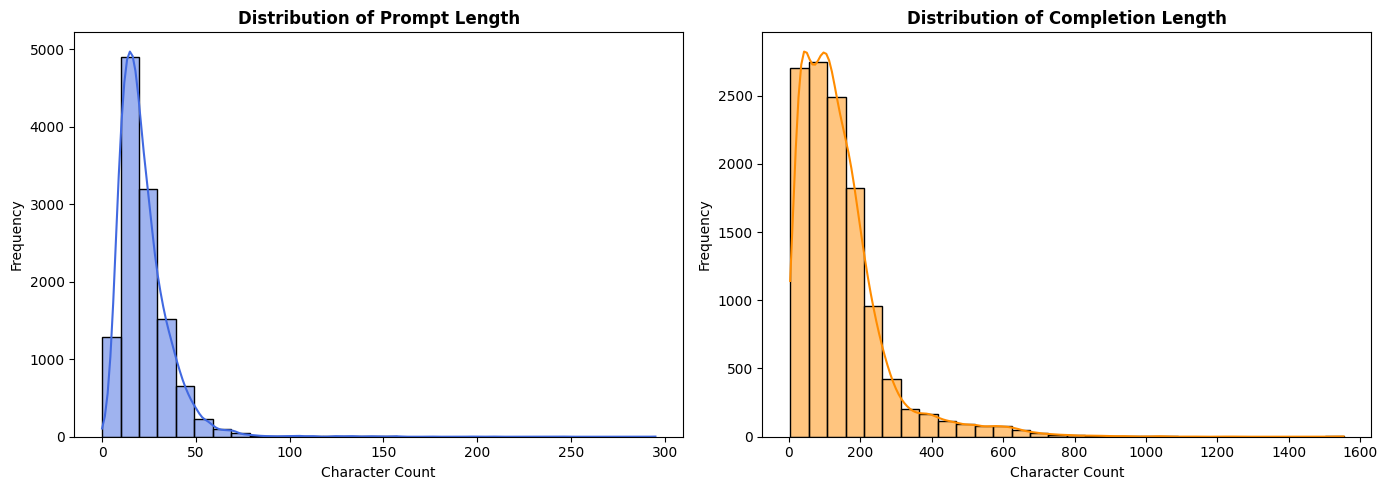

In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. 데이터 로드 및 데이터프레임 변환
data_path = 'KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl'
with open(data_path, "r", encoding="utf-8-sig") as f:
    sft_data = json.load(f)

df = pd.DataFrame(sft_data)

# 2. 질문과 답변의 글자 수(Length) 계산하여 컬럼 추가
df['prompt_len'] = df['prompt'].apply(len)
df['completion_len'] = df['completion'].apply(len)

# 3. 주요 통계치 출력 (수치적 분포 확인)
print("=== 📝 질문(Prompt) 글자 수 통계 ===")
print(df['prompt_len'].describe())
print("\n=== 🎯 답변(Completion) 글자 수 통계 ===")
print(df['completion_len'].describe())

# 4. 시각적 분포 확인을 위한 그래프 그리기 (히스토그램 & 커널밀도추정)
plt.figure(figsize=(14, 5))

# 질문 길이 분포 그래프
plt.subplot(1, 2, 1)
sns.histplot(df['prompt_len'], kde=True, color='royalblue', bins=30)
plt.title('Distribution of Prompt Length', fontsize=12, fontweight='bold')
plt.xlabel('Character Count')
plt.ylabel('Frequency')

# 답변 길이 분포 그래프
plt.subplot(1, 2, 2)
sns.histplot(df['completion_len'], kde=True, color='darkorange', bins=30)
plt.title('Distribution of Completion Length', fontsize=12, fontweight='bold')
plt.xlabel('Character Count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()